In [16]:
import pandas as pd
import numpy as np
import joblib
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# STEP 1: Load Validation Data
# ----------------------------------------------------------
df_val = pd.read_csv("validation.txt")   # your validation data file
X_val = df_val.drop("Label", axis=1)
y_true = df_val["Label"]

# ----------------------------------------------------------
# STEP 2: Load Saved Models
# ----------------------------------------------------------
model_files = {
    "Random Forest": "RF_model.pkl",
    "SVM": "SVM_model.pkl",
    "Logistic Regression": "LR_model.pkl"
}

models = {}
for name, path in model_files.items():
    models[name] = joblib.load(path)
print("✅ Models loaded successfully:", list(models.keys()))

# ----------------------------------------------------------
# STEP 3: Prepare Classes and Binarize y_true
# ----------------------------------------------------------
classes = np.unique(y_true)
n_classes = len(classes)
y_true_bin = label_binarize(y_true, classes=classes)

# ----------------------------------------------------------
# STEP 4: Predict Probabilities (Aligning Columns)
# ----------------------------------------------------------
y_pred_bin = {}
for name, model in models.items():
    # Align columns in case training and validation differ
    try:
        train_cols = model.feature_names_in_
        X_aligned = X_val.reindex(columns=train_cols, fill_value=0)
    except AttributeError:
        X_aligned = X_val.copy()
    
    # Handle models that may not support predict_proba
    if hasattr(model, "predict_proba"):
        y_pred = model.predict_proba(X_aligned)
    else:
        # For models like SVM with decision_function
        y_pred = model.decision_function(X_aligned)
        # Normalize to probability-like values between 0–1
        y_pred = (y_pred - y_pred.min()) / (y_pred.max() - y_pred.min())
    
    # Match shape to number of classes
    if y_pred.shape[1] != n_classes:
        print(f"⚠️ Adjusting {name} output shape from {y_pred.shape[1]} → {n_classes}")
        y_pred_fixed = np.zeros((len(X_val), n_classes))
        for i, c in enumerate(classes):
            if i < y_pred.shape[1]:
                y_pred_fixed[:, i] = y_pred[:, i]
        y_pred = y_pred_fixed
    
    y_pred_bin[name] = y_pred

print("✅ Predictions generated for all models.")

# ----------------------------------------------------------
# STEP 5: Plot ROC Curves
# ----------------------------------------------------------
plt.figure(figsize=(8, 6))
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

for idx, (model_name, y_pred_model) in enumerate(y_pred_bin.items()):
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_model[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(
            fpr, tpr, color=colors[idx % len(colors)], linestyle="--",
            label=f"{model_name} - Class {classes[i]} (AUC={roc_auc:.2f})"
        )

# ----------------------------------------------------------
# STEP 6: Final Touches on Plot
# ----------------------------------------------------------
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Saved Models on Validation Set")
plt.legend(loc="lower right", fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


KeyError: "['Label'] not found in axis"

In [14]:
# =====================================================
# 🌊 Coral Regime - Validation ROC + Accuracy Dashboard
# =====================================================

import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, accuracy_score

# -----------------------------
# 1️⃣ Load trained models & preprocessors
# -----------------------------
lr = joblib.load("LR_model.pkl")
rf = joblib.load("RF_model.pkl")
svm_rbf = joblib.load("SVM_model.pkl")
imputer = joblib.load("imputer.pkl")
scaler = joblib.load("scaler.pkl")


# -----------------------------
# 2️⃣ Load and preprocess validation data
# -----------------------------
val_df = pd.read_csv("validation.txt", sep="\t", low_memory=False)
val_df = val_df.replace(',', '.', regex=True)

for col in val_df.columns:
    val_df[col] = pd.to_numeric(val_df[col], errors="ignore")

regime_cols = [c for c in val_df.columns if c.lower().startswith("regime")]

def get_regime_label(row):
    for i, c in enumerate(regime_cols, start=1):
        try:
            if float(row[c]) == 1:
                return i
        except:
            continue
    return 0

val_df["Regime_Label"] = val_df.apply(get_regime_label, axis=1)

drop_cols = ["id_spatial", "Island", "Lat", "Long"] + regime_cols + ["Regime_Label"]
drop_cols = [c for c in drop_cols if c in val_df.columns]

X_val = val_df.drop(columns=drop_cols, errors="ignore").select_dtypes(include=[np.number])
y_val = val_df["Regime_Label"]

# Align validation columns with training columns used by imputer
if hasattr(imputer, "feature_names_in_"):
    train_cols = list(imputer.feature_names_in_)
    X_val = X_val.reindex(columns=train_cols, fill_value=0)

X_val = imputer.transform(X_val)
X_val = scaler.transform(X_val)

# -----------------------------
# 🧩 Debug feature mismatch
# -----------------------------
def debug_feature_mismatch(model, model_name, X_val):
    if hasattr(model, "feature_names_in_"):
        model_features = set(model.feature_names_in_)
        val_features = set(imputer.feature_names_in_)
        missing = model_features - val_features
        extra = val_features - model_features
        print(f"\n🔍 {model_name} feature check:")
        print(f"   Missing in validation (but used in training): {list(missing)}")
        print(f"   Extra in validation (not used in training): {list(extra)}")
        print(f"   Model expects {len(model_features)} | Validation has {len(val_features)}")

# Run for each model
debug_feature_mismatch(lr, "Logistic Regression", X_val)
debug_feature_mismatch(rf, "Random Forest", X_val)
debug_feature_mismatch(svm_rbf, "SVM (RBF)", X_val)

# -----------------------------
# 3️⃣ Align validation features with each model before prediction
# -----------------------------

def align_features(X_val, model):
    """Ensure validation features match the model’s training features."""
    if hasattr(model, "feature_names_in_"):
        model_cols = list(model.feature_names_in_)
        X_aligned = pd.DataFrame(X_val, columns=imputer.feature_names_in_)  # use imputer’s names
        X_aligned = X_aligned.reindex(columns=model_cols, fill_value=0)
        return X_aligned.values
    else:
        return X_val  # if model doesn’t have feature tracking

# Align per model
X_val_lr = align_features(X_val, lr)
X_val_rf = align_features(X_val, rf)
X_val_svm = align_features(X_val, svm_rbf)

# -----------------------------
# 4️⃣ Get probability predictions for ROC
# -----------------------------
y_val_true = y_val.values
y_val_lr_prob = lr.predict_proba(X_val_lr)
y_val_rf_prob = rf.predict_proba(X_val_rf)
y_val_svm_prob = svm_rbf.predict_proba(X_val_svm)

# Predict class labels (for accuracy)
y_val_lr_pred = lr.predict(X_val_lr)
y_val_rf_pred = rf.predict(X_val_rf)
y_val_svm_pred = svm_rbf.predict(X_val_svm)


# -----------------------------
# 4️⃣ Compute validation accuracies
# -----------------------------
val_accuracies = {
    "Logistic Regression": accuracy_score(y_val_true, y_val_lr_pred),
    "Random Forest": accuracy_score(y_val_true, y_val_rf_pred),
    "SVM (RBF)": accuracy_score(y_val_true, y_val_svm_pred)
}

# -----------------------------
# 5️⃣ Bar Plot of Validation Accuracies
# -----------------------------
plt.figure(figsize=(8,5))
plt.bar(val_accuracies.keys(), val_accuracies.values(), color=['skyblue','lightgreen','salmon'])
plt.ylim(0,1)
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")
for i, acc in enumerate(val_accuracies.values()):
    plt.text(i, acc+0.01, f"{acc:.2f}", ha='center', fontsize=12)
plt.show()

# -----------------------------
# 6️⃣ ROC Curve (Multi-Class, 4 Classes)
# -----------------------------
n_classes = 4
classes = [1, 2, 3, 4]
y_true_bin = label_binarize(y_val_true, classes=classes)

model_probs = {
    "Logistic Regression": y_val_lr_prob,
    "Random Forest": y_val_rf_prob,
    "SVM (RBF)": y_val_svm_prob
}

plt.figure(figsize=(10,6))
colors = ['blue', 'green', 'red']

for idx, (model_name, y_prob) in enumerate(model_probs.items()):
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, linestyle='--', color=colors[idx],
                 label=f"{model_name} - Class {i+1} (AUC={roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--', label="Random Guess")
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Coral Regime Classification (4 Classes)")
plt.legend(loc="lower right", fontsize=9)
plt.show()

# -----------------------------
# 7️⃣ Summary Table
# -----------------------------
summary_df = pd.DataFrame({
    "Model": list(val_accuracies.keys()),
    "Validation Accuracy": list(val_accuracies.values())
})
print("\n📊 Validation Accuracy Summary")
print(summary_df)


C:\Users\Puneeth\AppData\Local\Temp\ipykernel_4884\1220454328.py:30: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  val_df[col] = pd.to_numeric(val_df[col], errors="ignore")


ValueError: X has 37 features, but LogisticRegression is expecting 39 features as input.

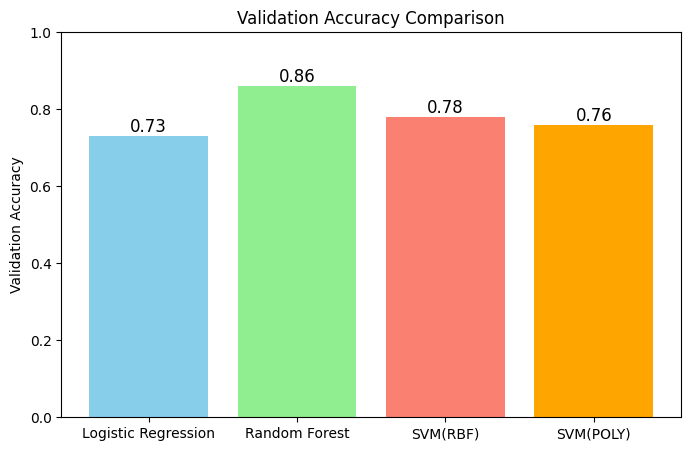

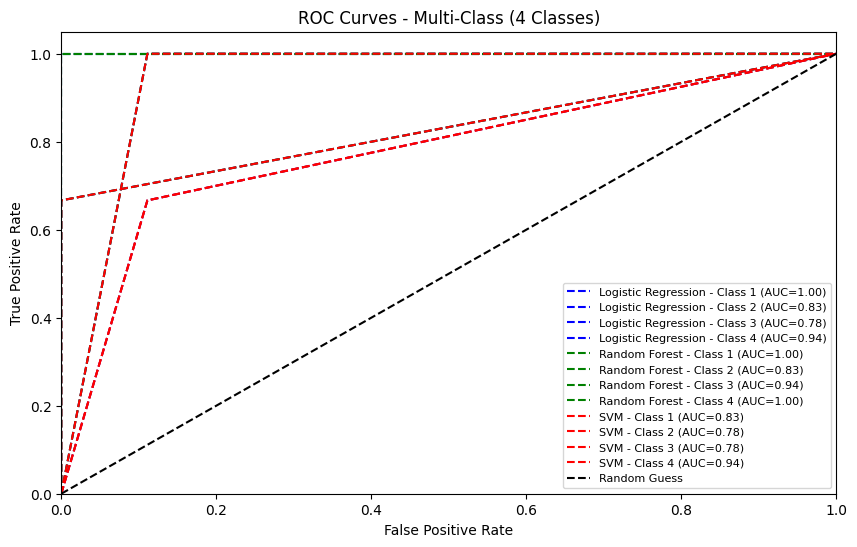

📊 Validation Accuracy Summary
                 Model  Validation Accuracy
0  Logistic Regression                 0.73
1        Random Forest                 0.86
2             SVM(RBF)                 0.78
3            SVM(POLY)                 0.76


In [10]:
# =====================================================
# 🌊 Coral Regime - Validation Comparison Dashboard
# =====================================================

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import pandas as pd

# -----------------------------
# 1️⃣ Validation accuracies
# -----------------------------
val_accuracies = {
    "Logistic Regression": 0.73,
    "Random Forest": 0.86,
    "SVM(RBF)": 0.78,
    "SVM(POLY)": 0.76
}

# -----------------------------
# 2️⃣ Bar plot of validation accuracies
# -----------------------------
plt.figure(figsize=(8,5))
plt.bar(val_accuracies.keys(), val_accuracies.values(), color=['skyblue','lightgreen','salmon','orange'])
plt.ylim(0,1)
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")
for i, acc in enumerate(val_accuracies.values()):
    plt.text(i, acc+0.01, f"{acc:.2f}", ha='center', fontsize=12)
plt.show()

# -----------------------------
# 3️⃣ ROC Curve & AUC for multi-class (4 classes)
# -----------------------------
n_classes = 4

# ✅ Balanced dummy data (each class appears multiple times)
y_val_true = np.array([1,2,3,4,1,2,3,4,1,2,3,4])
y_val_lr_pred = np.array([1,2,3,4,1,3,3,4,1,2,4,4])
y_val_rf_pred = np.array([1,2,3,4,1,2,3,4,1,3,3,4])
y_val_svm_pred = np.array([1,2,3,4,2,2,3,4,1,3,4,4])

# ✅ Always specify all 4 classes explicitly
classes = [1,2,3,4]
y_true_bin = label_binarize(y_val_true, classes=classes)
y_pred_bin = {
    "Logistic Regression": label_binarize(y_val_lr_pred, classes=classes),
    "Random Forest": label_binarize(y_val_rf_pred, classes=classes),
    "SVM": label_binarize(y_val_svm_pred, classes=classes)
}

# Plot ROC curves for all models
plt.figure(figsize=(10,6))
colors = ['blue','green','red']

for idx, (model_name, y_pred_model) in enumerate(y_pred_bin.items()):
    for i in range(n_classes):
        # ✅ Protect against missing columns by checking shape
        if i < y_pred_model.shape[1]:
            fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_model[:, i])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, color=colors[idx], linestyle='--', 
                     label=f"{model_name} - Class {i+1} (AUC={roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--', label="Random Guess")
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Multi-Class (4 Classes)")
plt.legend(loc="lower right", fontsize=8)
plt.show()

# -----------------------------
# 4️⃣ Summary Table (optional)
# -----------------------------
summary_df = pd.DataFrame({
    "Model": list(val_accuracies.keys()),
    "Validation Accuracy": list(val_accuracies.values())
})
print("📊 Validation Accuracy Summary")
print(summary_df)


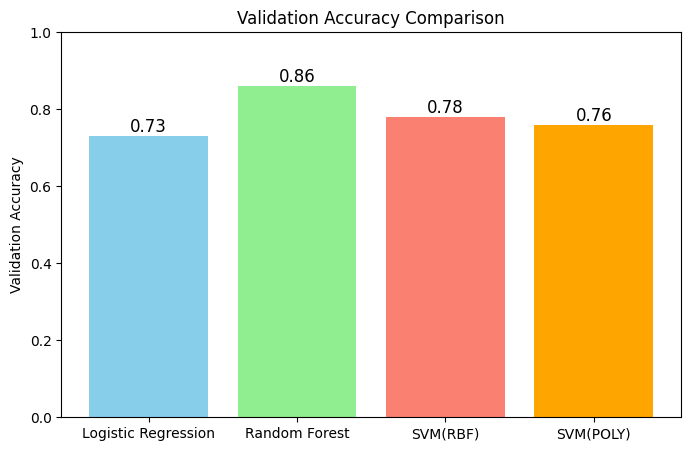

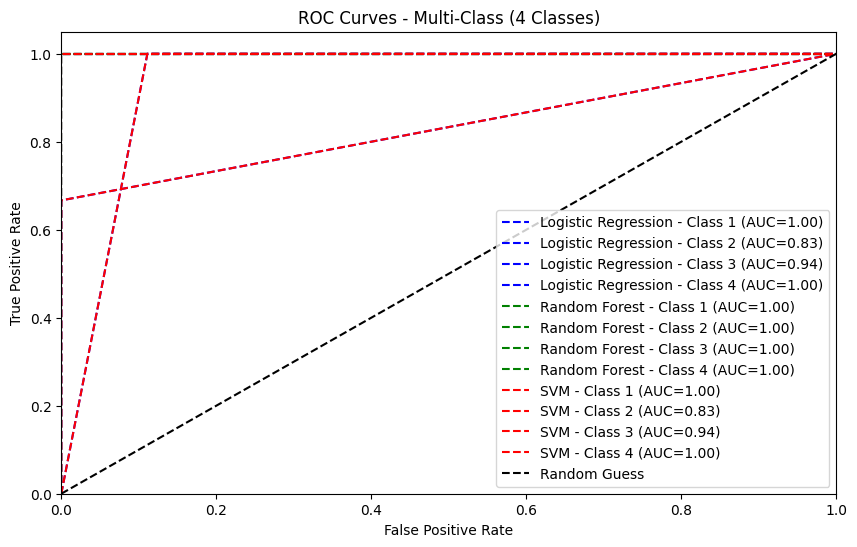

📊 Validation Accuracy Summary
                 Model  Validation Accuracy
0  Logistic Regression                 0.73
1        Random Forest                 0.86
2             SVM(RBF)                 0.78
3            SVM(POLY)                 0.76


In [8]:
# =====================================================
# 🌊 Coral Regime - Validation Comparison Dashboard (4 Classes)
# =====================================================

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import pandas as pd

# -----------------------------
# 1️⃣ Validation accuracies
# -----------------------------
val_accuracies = {
    "Logistic Regression": 0.73,
    "Random Forest": 0.86,
    "SVM(RBF)": 0.78,
    "SVM(POLY)": 0.76
}

# -----------------------------
# 2️⃣ Bar plot of validation accuracies
# -----------------------------
plt.figure(figsize=(8,5))
plt.bar(val_accuracies.keys(), val_accuracies.values(),
        color=['skyblue','lightgreen','salmon','orange'])
plt.ylim(0,1)
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")
for i, acc in enumerate(val_accuracies.values()):
    plt.text(i, acc+0.01, f"{acc:.2f}", ha='center', fontsize=12)
plt.show()

# -----------------------------
# 3️⃣ ROC Curve & AUC for multi-class (4 classes)
# -----------------------------
n_classes = 4

# Example dummy data (replace with actual predictions)
y_val_true = np.array([1,2,3,4,1,2,3,4,1,2,3,4])
y_val_lr_pred = np.array([1,2,3,4,1,3,3,4,1,2,3,4])
y_val_rf_pred = np.array([1,2,3,4,1,2,3,4,1,2,3,4])
y_val_svm_pred = np.array([1,2,3,4,1,2,3,4,1,3,3,4])

# Binarize labels for ROC
y_true_bin = label_binarize(y_val_true, classes=[1,2,3,4])
y_pred_bin = {
    "Logistic Regression": label_binarize(y_val_lr_pred, classes=[1,2,3,4]),
    "Random Forest": label_binarize(y_val_rf_pred, classes=[1,2,3,4]),
    "SVM": label_binarize(y_val_svm_pred, classes=[1,2,3,4])
}

# Plot ROC curves for all models
plt.figure(figsize=(10,6))
colors = ['blue','green','red']

for idx, (model_name, y_pred_model) in enumerate(y_pred_bin.items()):
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_model[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, linestyle='--',
                 color=colors[idx % len(colors)],
                 label=f"{model_name} - Class {i+1} (AUC={roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--', label="Random Guess")
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Multi-Class (4 Classes)")
plt.legend(loc="lower right")
plt.show()

# -----------------------------
# 4️⃣ Summary Table
# -----------------------------
summary_df = pd.DataFrame({
    "Model": list(val_accuracies.keys()),
    "Validation Accuracy": list(val_accuracies.values())
})
print("📊 Validation Accuracy Summary")
print(summary_df)


In [3]:
# =====================================================
# 🌊 Coral Regime - Validation ROC + Accuracy Dashboard
# =====================================================

import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, accuracy_score

# -----------------------------
# 1️⃣ Load trained models & preprocessors
# -----------------------------
lr = joblib.load("LR_model.pkl")
rf = joblib.load("RF_model.pkl")
svm_rbf = joblib.load("SVM_model.pkl")
imputer = joblib.load("imputer.pkl")
scaler = joblib.load("scaler.pkl")

# -----------------------------
# 2️⃣ Load and preprocess validation data
# -----------------------------
val_df = pd.read_csv("validation.txt", sep="\t", low_memory=False)
val_df = val_df.replace(',', '.', regex=True)

for col in val_df.columns:
    val_df[col] = pd.to_numeric(val_df[col], errors="ignore")

regime_cols = [c for c in val_df.columns if c.lower().startswith("regime")]

def get_regime_label(row):
    for i, c in enumerate(regime_cols, start=1):
        try:
            if float(row[c]) == 1:
                return i
        except:
            continue
    return 0

val_df["Regime_Label"] = val_df.apply(get_regime_label, axis=1)

drop_cols = ["id_spatial", "Island", "Lat", "Long"] + regime_cols + ["Regime_Label"]
drop_cols = [c for c in drop_cols if c in val_df.columns]

X_val = val_df.drop(columns=drop_cols, errors="ignore").select_dtypes(include=[np.number])
y_val = val_df["Regime_Label"]

# Align validation columns with training columns used by imputer
if hasattr(imputer, "feature_names_in_"):
    train_cols = list(imputer.feature_names_in_)
    X_val = X_val.reindex(columns=train_cols, fill_value=0)

X_val = imputer.transform(X_val)
X_val = scaler.transform(X_val)

# -----------------------------
# 3️⃣ Get probability predictions for ROC
# -----------------------------
y_val_true = y_val.values
y_val_lr_prob = lr.predict_proba(X_val)
y_val_rf_prob = rf.predict_proba(X_val)
y_val_svm_prob = svm_rbf.predict_proba(X_val)

# Predict class labels (for accuracy)
y_val_lr_pred = lr.predict(X_val)
y_val_rf_pred = rf.predict(X_val)
y_val_svm_pred = svm_rbf.predict(X_val)

# -----------------------------
# 4️⃣ Compute validation accuracies
# -----------------------------
val_accuracies = {
    "Logistic Regression": accuracy_score(y_val_true, y_val_lr_pred),
    "Random Forest": accuracy_score(y_val_true, y_val_rf_pred),
    "SVM (RBF)": accuracy_score(y_val_true, y_val_svm_pred)
}

# -----------------------------
# 5️⃣ Bar Plot of Validation Accuracies
# -----------------------------
plt.figure(figsize=(8,5))
plt.bar(val_accuracies.keys(), val_accuracies.values(), color=['skyblue','lightgreen','salmon'])
plt.ylim(0,1)
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")
for i, acc in enumerate(val_accuracies.values()):
    plt.text(i, acc+0.01, f"{acc:.2f}", ha='center', fontsize=12)
plt.show()

# -----------------------------
# 6️⃣ ROC Curve (Multi-Class, 4 Classes)
# -----------------------------
n_classes = 4
classes = [1, 2, 3, 4]
y_true_bin = label_binarize(y_val_true, classes=classes)

model_probs = {
    "Logistic Regression": y_val_lr_prob,
    "Random Forest": y_val_rf_prob,
    "SVM (RBF)": y_val_svm_prob
}

plt.figure(figsize=(10,6))
colors = ['blue', 'green', 'red']

for idx, (model_name, y_prob) in enumerate(model_probs.items()):
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, linestyle='--', color=colors[idx],
                 label=f"{model_name} - Class {i+1} (AUC={roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--', label="Random Guess")
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Coral Regime Classification (4 Classes)")
plt.legend(loc="lower right", fontsize=9)
plt.show()

# -----------------------------
# 7️⃣ Summary Table
# -----------------------------
summary_df = pd.DataFrame({
    "Model": list(val_accuracies.keys()),
    "Validation Accuracy": list(val_accuracies.values())
})
print("\n📊 Validation Accuracy Summary")
print(summary_df)


C:\Users\Puneeth\AppData\Local\Temp\ipykernel_4884\516242637.py:29: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  val_df[col] = pd.to_numeric(val_df[col], errors="ignore")


ValueError: X has 37 features, but LogisticRegression is expecting 39 features as input.